# NB04: Cross-Organism Conservation of Support Networks

Test H4: do the same functional categories recur in AMR support networks across organisms?

Given the NB03 finding that AMR support networks are NOT functionally distinctive within
organisms, this notebook asks: are the *same* generic partners conserved? If membrane genes
appear as AMR cofitness partners in 24% of organisms (NB03 permutation), do the same
KEGG groups recur, or are they different membrane genes each time?

**Also**: test whether efflux, enzymatic, and metal AMR genes recruit *different* support
functions from each other, even if none is enriched vs genome background.

**Inputs:** `data/amr_cofitness_partners.csv`, KEGG/SEED annotations

**Outputs:** `data/conserved_support_network.csv`, figures

In [1]:
import os
import warnings
from collections import Counter
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_cofitness_networks')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_cofitness_networks')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
FM_DATA = os.path.join(REPO, 'projects', 'fitness_modules', 'data')
AMR_DATA = os.path.join(REPO, 'projects', 'amr_fitness_cost', 'data')

# Load partners with annotations
partners = pd.read_csv(os.path.join(DATA, 'amr_cofitness_partners.csv'))
partners['amr_locusId'] = partners['amr_locusId'].astype(str)
partners['partner_locusId'] = partners['partner_locusId'].astype(str)

# Extra-operon only
extra = partners[~partners['is_near_operon']].copy()
print(f'Extra-operon partners: {len(extra):,}')

# Load KEGG annotations for cross-organism comparison
all_kegg = []
for org in extra['orgId'].unique():
    kegg_f = os.path.join(FM_DATA, 'annotations', f'{org}_kegg.csv')
    if os.path.exists(kegg_f):
        df = pd.read_csv(kegg_f)
        df['locusId'] = df['locusId'].astype(str)
        df['orgId'] = org
        all_kegg.append(df)

kegg_annot = pd.concat(all_kegg, ignore_index=True)
# Deduplicate: one KEGG group per gene
kegg_annot = kegg_annot.drop_duplicates(subset=['orgId', 'locusId'], keep='first')
print(f'KEGG annotations: {len(kegg_annot)} gene-KEGG pairs')
print(f'Unique KEGG groups: {kegg_annot["kgroup"].nunique()}')

Extra-operon partners: 179,375
KEGG annotations: 59754 gene-KEGG pairs
Unique KEGG groups: 4771


## 1. KEGG group recurrence across organisms

For each AMR mechanism, which KEGG groups appear in support networks across multiple organisms?

In [2]:
# Partners already have partner_kgroup from NB01 annotation merge
# Just filter to those with KEGG annotations
with_kegg = extra[extra['partner_kgroup'].notna()].copy()
print(f'Partners with KEGG: {len(with_kegg):,} / {len(extra):,}')

# For each mechanism, count how many organisms each KEGG group appears in
# Use kegg_annot for descriptions
desc_map = dict(zip(kegg_annot['kgroup'], kegg_annot['kgroup_desc']))

for mech in ['efflux', 'enzymatic_inactivation', 'metal_resistance']:
    mech_partners = with_kegg[with_kegg['amr_mechanism'] == mech]
    n_orgs = mech_partners['orgId'].nunique()
    
    # Count organisms per KEGG group
    kg_org_counts = mech_partners.groupby('partner_kgroup')['orgId'].nunique().reset_index()
    kg_org_counts.columns = ['kgroup', 'n_organisms']
    kg_org_counts = kg_org_counts.sort_values('n_organisms', ascending=False)
    kg_org_counts['desc'] = kg_org_counts['kgroup'].map(desc_map)
    
    # Conserved: present in >50% of organisms
    conserved = kg_org_counts[kg_org_counts['n_organisms'] >= n_orgs * 0.5]
    
    print(f'\n=== {mech} (N={n_orgs} organisms) ===')
    print(f'Unique KEGG groups in support networks: {len(kg_org_counts)}')
    print(f'Conserved (>={n_orgs*0.5:.0f} organisms = 50%): {len(conserved)}')
    if len(conserved) > 0:
        print('Top conserved KEGG groups:')
        for _, row in conserved.head(15).iterrows():
            desc = str(row['desc'])[:60] if pd.notna(row['desc']) else '?'
            print(f'  {row["kgroup"]:10s} {row["n_organisms"]:2.0f}/{n_orgs} orgs  {desc}')


Partners with KEGG: 73,687 / 179,375



=== efflux (N=28 organisms) ===
Unique KEGG groups in support networks: 3094
Conserved (>=14 organisms = 50%): 20
Top conserved KEGG groups:
  K02014     20/28 orgs  iron complex outermembrane recepter protein
  K01652     19/28 orgs  acetolactate synthase I/II/III large subunit 
  K03088     18/28 orgs  RNA polymerase sigma-70 factor, ECF subfamily
  K02495     16/28 orgs  oxygen-independent coproporphyrinogen III oxidase 
  K03406     15/28 orgs  methyl-accepting chemotaxis protein
  K09686     15/28 orgs  antibiotic transport system permease protein
  K02004     15/28 orgs  ?
  K02066     15/28 orgs  putative ABC transport system permease protein
  K03657     15/28 orgs  DNA helicase II / ATP-dependent DNA helicase PcrA 
  K00058     15/28 orgs  D-3-phosphoglycerate dehydrogenase 
  K00052     15/28 orgs  3-isopropylmalate dehydrogenase 
  K00817     15/28 orgs  histidinol-phosphate aminotransferase 
  K04754     15/28 orgs  lipoprotein
  K01256     14/28 orgs  aminopeptidase N 
  

## 2. Do different mechanisms recruit different support functions?

In [3]:
# Build a mechanism × KEGG group matrix
# For each mechanism, fraction of organisms where each KEGG group appears in support networks

mechanisms = ['efflux', 'enzymatic_inactivation', 'metal_resistance']
all_kgroups = set()

mech_kg_data = {}
for mech in mechanisms:
    mech_partners = with_kegg[with_kegg['amr_mechanism'] == mech]
    n_orgs = mech_partners['orgId'].nunique()
    kg_orgs = mech_partners.groupby('partner_kgroup')['orgId'].nunique()
    mech_kg_data[mech] = (kg_orgs / n_orgs * 100)  # % of organisms
    all_kgroups.update(kg_orgs.index)

# Build comparison matrix for KEGG groups present in >25% of orgs for ANY mechanism
comparison = pd.DataFrame(index=sorted(all_kgroups))
for mech in mechanisms:
    comparison[mech] = mech_kg_data[mech]
comparison = comparison.fillna(0)

# Filter to KEGG groups present in >25% of organisms for at least one mechanism
mask = (comparison > 25).any(axis=1)
comparison_filtered = comparison[mask].copy()

# Add descriptions
desc_map = dict(zip(kegg_annot['kgroup'], kegg_annot['kgroup_desc']))
comparison_filtered['desc'] = comparison_filtered.index.map(desc_map)

print(f'KEGG groups in >25% of organisms for any mechanism: {len(comparison_filtered)}')
print()

# Sort by max across mechanisms
comparison_filtered['max_pct'] = comparison_filtered[mechanisms].max(axis=1)
comparison_filtered = comparison_filtered.sort_values('max_pct', ascending=False)

for _, row in comparison_filtered.head(30).iterrows():
    desc = str(row['desc'])[:50] if pd.notna(row['desc']) else '?'
    print(f'  {row.name:10s}  eff={row["efflux"]:5.1f}%  enz={row["enzymatic_inactivation"]:5.1f}%  '
          f'met={row["metal_resistance"]:5.1f}%  {desc}')

KEGG groups in >25% of organisms for any mechanism: 476

  K02014      eff= 71.4%  enz= 65.4%  met= 78.3%  iron complex outermembrane recepter protein
  K01652      eff= 67.9%  enz= 65.4%  met= 17.4%  acetolactate synthase I/II/III large subunit 
  K03088      eff= 64.3%  enz= 61.5%  met= 56.5%  RNA polymerase sigma-70 factor, ECF subfamily
  K00626      eff= 50.0%  enz= 61.5%  met= 47.8%  acetyl-CoA C-acetyltransferase 
  K02495      eff= 57.1%  enz= 57.7%  met= 39.1%  oxygen-independent coproporphyrinogen III oxidase 
  K01091      eff= 25.0%  enz= 57.7%  met= 26.1%  phosphoglycolate phosphatase 
  K01692      eff= 35.7%  enz= 57.7%  met= 39.1%  enoyl-CoA hydratase 
  K03406      eff= 53.6%  enz= 53.8%  met= 47.8%  methyl-accepting chemotaxis protein
  K01533      eff= 42.9%  enz= 53.8%  met= 47.8%  Cu2+-exporting ATPase 
  K07107      eff= 39.3%  enz= 53.8%  met= 30.4%  acyl-CoA thioester hydrolase 
  K07090      eff= 35.7%  enz= 53.8%  met= 21.7%  ?
  K01012      eff= 46.4%  enz= 5

In [4]:
# Test: are the KEGG group profiles different between mechanisms?
# For each KEGG group present in >25% for any mechanism,
# test whether its prevalence differs across mechanisms (chi-square)

mech_specific = []

for kg in comparison_filtered.index:
    # For each mechanism, count organisms with vs without this KEGG group
    contingency = []
    for mech in mechanisms:
        mech_partners = with_kegg[with_kegg['amr_mechanism'] == mech]
        orgs_total = mech_partners['orgId'].unique()
        orgs_with_kg = mech_partners[mech_partners['partner_kgroup'] == kg]['orgId'].unique()
        contingency.append([len(orgs_with_kg), len(orgs_total) - len(orgs_with_kg)])
    
    # Chi-square (or Fisher if small)
    table = np.array(contingency)
    if table.min() < 5:
        # Use Fisher for 2x3 via permutation chi2
        chi2, p = stats.chi2_contingency(table)[:2]
    else:
        chi2, p = stats.chi2_contingency(table)[:2]
    
    desc = desc_map.get(kg, '?')
    mech_specific.append({
        'kgroup': kg,
        'desc': str(desc)[:60] if pd.notna(desc) else '?',
        'efflux_pct': comparison_filtered.loc[kg, 'efflux'],
        'enzymatic_pct': comparison_filtered.loc[kg, 'enzymatic_inactivation'],
        'metal_pct': comparison_filtered.loc[kg, 'metal_resistance'],
        'chi2': chi2,
        'p_value': p,
    })

mech_spec_df = pd.DataFrame(mech_specific)
if len(mech_spec_df) > 0:
    _, q, _, _ = multipletests(mech_spec_df['p_value'], method='fdr_bh')
    mech_spec_df['q_value'] = q
    mech_spec_df['significant'] = q < 0.05
    
    print(f'KEGG groups tested for mechanism-specificity: {len(mech_spec_df)}')
    print(f'Significant after FDR: {mech_spec_df["significant"].sum()}')
    
    if mech_spec_df['significant'].any():
        print(f'\nMechanism-specific KEGG groups:')
        for _, row in mech_spec_df[mech_spec_df['significant']].sort_values('q_value').iterrows():
            print(f'  {row["kgroup"]:10s} eff={row["efflux_pct"]:5.1f}% enz={row["enzymatic_pct"]:5.1f}% '
                  f'met={row["metal_pct"]:5.1f}% q={row["q_value"]:.4g}  {row["desc"]}')
    else:
        print('\nNo mechanism-specific KEGG groups after FDR correction')
        print('Top candidates (lowest p):')
        for _, row in mech_spec_df.nsmallest(10, 'p_value').iterrows():
            print(f'  {row["kgroup"]:10s} eff={row["efflux_pct"]:5.1f}% enz={row["enzymatic_pct"]:5.1f}% '
                  f'met={row["metal_pct"]:5.1f}% p={row["p_value"]:.4g} q={row["q_value"]:.4g}  {row["desc"]}')

KEGG groups tested for mechanism-specificity: 476
Significant after FDR: 2

Mechanism-specific KEGG groups:
  K04754     eff= 53.6% enz= 11.5% met=  4.3% q=0.02049  lipoprotein
  K07323     eff= 50.0% enz= 11.5% met=  4.3% q=0.03305  putative toluene tolerance protein


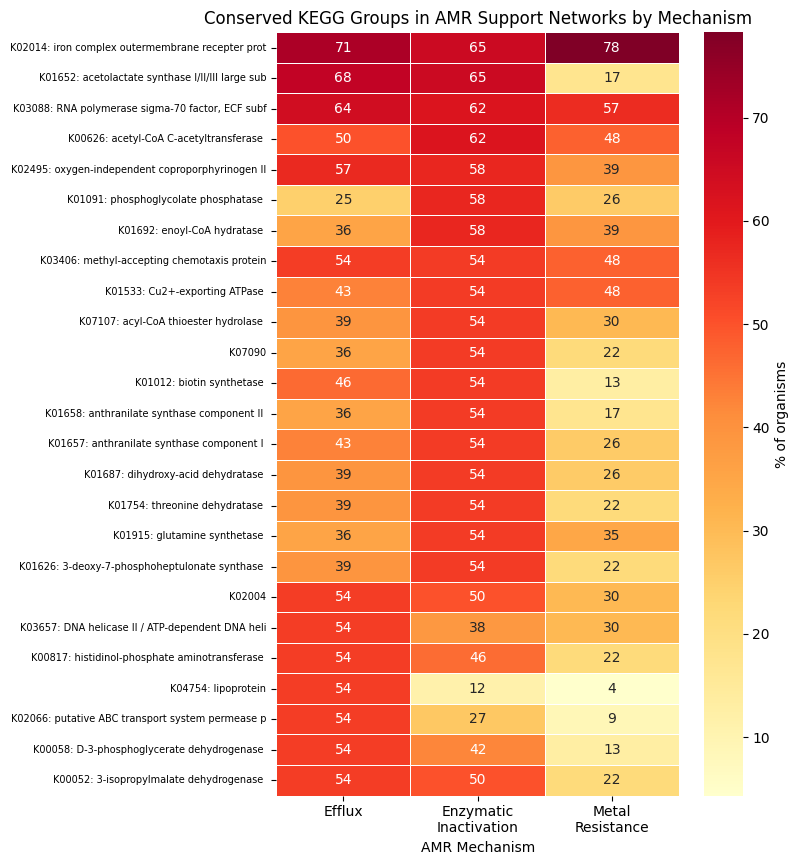

Saved to figures/conserved_kegg_by_mechanism.png


In [5]:
# Heatmap: top conserved KEGG groups by mechanism
if len(comparison_filtered) > 0:
    fig, ax = plt.subplots(figsize=(8, max(6, len(comparison_filtered.head(25)) * 0.35)))
    
    plot_data = comparison_filtered.head(25)[mechanisms]
    # Add descriptions as row labels
    labels = [f"{idx}: {str(comparison_filtered.loc[idx, 'desc'])[:40]}" 
              if pd.notna(comparison_filtered.loc[idx, 'desc']) else idx
              for idx in plot_data.index]
    plot_data.index = labels
    
    sns.heatmap(plot_data, cmap='YlOrRd', annot=True, fmt='.0f',
                cbar_kws={'label': '% of organisms'}, ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_title('Conserved KEGG Groups in AMR Support Networks by Mechanism')
    ax.set_xlabel('AMR Mechanism')
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xticklabels(['Efflux', 'Enzymatic\nInactivation', 'Metal\nResistance'],
                        rotation=0)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, 'conserved_kegg_by_mechanism.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to figures/conserved_kegg_by_mechanism.png')

## 3. Jaccard similarity of support networks across organisms

In [6]:
# For each pair of organisms, compute Jaccard similarity of their AMR support
# network KEGG groups (within same mechanism)

from itertools import combinations

jaccard_results = []

for mech in mechanisms:
    mech_partners = with_kegg[with_kegg['amr_mechanism'] == mech]
    orgs = sorted(mech_partners['orgId'].unique())
    
    # KEGG groups per organism
    org_kgroups = {}
    for org in orgs:
        org_data = mech_partners[mech_partners['orgId'] == org]
        org_kgroups[org] = set(org_data['partner_kgroup'].unique())
    
    # Pairwise Jaccard
    for o1, o2 in combinations(orgs, 2):
        s1, s2 = org_kgroups[o1], org_kgroups[o2]
        if len(s1) == 0 or len(s2) == 0:
            continue
        jaccard = len(s1 & s2) / len(s1 | s2)
        jaccard_results.append({
            'mechanism': mech,
            'org1': o1, 'org2': o2,
            'jaccard': jaccard,
            'shared': len(s1 & s2),
            'union': len(s1 | s2),
        })

jaccard_df = pd.DataFrame(jaccard_results)

print('=== Cross-organism Jaccard similarity of support network KEGG groups ===')
for mech in mechanisms:
    sub = jaccard_df[jaccard_df['mechanism'] == mech]
    if len(sub) > 0:
        print(f'  {mech:30s}: mean J={sub["jaccard"].mean():.3f}, '
              f'median={sub["jaccard"].median():.3f}, N={len(sub)} pairs')

# Compare: is Jaccard higher within-mechanism than across-mechanism?
# (i.e., do efflux networks share more KEGG groups with other efflux networks
#  than with enzymatic networks?)
print(f'\nWithin-mechanism mean Jaccard: {jaccard_df["jaccard"].mean():.3f}')

=== Cross-organism Jaccard similarity of support network KEGG groups ===
  efflux                        : mean J=0.070, median=0.049, N=378 pairs
  enzymatic_inactivation        : mean J=0.085, median=0.061, N=325 pairs
  metal_resistance              : mean J=0.048, median=0.033, N=253 pairs

Within-mechanism mean Jaccard: 0.069


In [7]:
# Cross-mechanism Jaccard for comparison
cross_jaccard = []
for mech1, mech2 in combinations(mechanisms, 2):
    orgs1 = with_kegg[with_kegg['amr_mechanism'] == mech1]['orgId'].unique()
    orgs2 = with_kegg[with_kegg['amr_mechanism'] == mech2]['orgId'].unique()
    shared_orgs = set(orgs1) & set(orgs2)
    
    for org in shared_orgs:
        kg1 = set(with_kegg[(with_kegg['amr_mechanism'] == mech1) & 
                            (with_kegg['orgId'] == org)]['partner_kgroup'].unique())
        kg2 = set(with_kegg[(with_kegg['amr_mechanism'] == mech2) & 
                            (with_kegg['orgId'] == org)]['partner_kgroup'].unique())
        if len(kg1) == 0 or len(kg2) == 0:
            continue
        j = len(kg1 & kg2) / len(kg1 | kg2)
        cross_jaccard.append({
            'comparison': f'{mech1} vs {mech2}',
            'orgId': org,
            'jaccard': j,
        })

cross_df = pd.DataFrame(cross_jaccard)

print('=== Within-organism, cross-mechanism Jaccard ===')
print(f'(Do different AMR mechanisms in the same organism share support partners?)')
for comp in cross_df['comparison'].unique():
    sub = cross_df[cross_df['comparison'] == comp]
    print(f'  {comp:45s}: mean J={sub["jaccard"].mean():.3f}, N={len(sub)} organisms')

print(f'\nOverall cross-mechanism mean Jaccard: {cross_df["jaccard"].mean():.3f}')
print(f'Overall within-mechanism mean Jaccard: {jaccard_df["jaccard"].mean():.3f}')

# Test: within-mechanism > cross-mechanism?
if len(jaccard_df) > 5 and len(cross_df) > 5:
    u, p = stats.mannwhitneyu(jaccard_df['jaccard'], cross_df['jaccard'], alternative='greater')
    print(f'\nWithin > Cross mechanism Jaccard: MWU p={p:.4g}')

=== Within-organism, cross-mechanism Jaccard ===
(Do different AMR mechanisms in the same organism share support partners?)
  efflux vs enzymatic_inactivation             : mean J=0.283, N=26 organisms
  efflux vs metal_resistance                   : mean J=0.206, N=23 organisms
  enzymatic_inactivation vs metal_resistance   : mean J=0.254, N=22 organisms

Overall cross-mechanism mean Jaccard: 0.249
Overall within-mechanism mean Jaccard: 0.069

Within > Cross mechanism Jaccard: MWU p=1


## 4. Save and summarize

In [8]:
# Save results
if len(mech_spec_df) > 0:
    mech_spec_df.to_csv(os.path.join(DATA, 'conserved_support_network.csv'), index=False)
jaccard_df.to_csv(os.path.join(DATA, 'jaccard_within_mechanism.csv'), index=False)
cross_df.to_csv(os.path.join(DATA, 'jaccard_cross_mechanism.csv'), index=False)

print('=== NB04 Summary ===')
print(f'H4 (conserved support networks):')
for mech in mechanisms:
    sub = jaccard_df[jaccard_df['mechanism'] == mech]
    print(f'  {mech}: cross-organism Jaccard = {sub["jaccard"].mean():.3f}')
print(f'\nWithin-mechanism Jaccard ({jaccard_df["jaccard"].mean():.3f}) vs '
      f'cross-mechanism ({cross_df["jaccard"].mean():.3f})')
if len(jaccard_df) > 5 and len(cross_df) > 5:
    print(f'  MWU p={p:.4g}')
print(f'\nMechanism-specific KEGG groups (FDR<0.05): {mech_spec_df["significant"].sum() if len(mech_spec_df) > 0 else 0}')

=== NB04 Summary ===
H4 (conserved support networks):
  efflux: cross-organism Jaccard = 0.070
  enzymatic_inactivation: cross-organism Jaccard = 0.085
  metal_resistance: cross-organism Jaccard = 0.048

Within-mechanism Jaccard (0.069) vs cross-mechanism (0.249)
  MWU p=1

Mechanism-specific KEGG groups (FDR<0.05): 2
